# Task 1 — Logistic Regression from Scratch

Implements binary Logistic Regression from scratch, then extends to multi-class via One-vs-Rest (OvR).

**Restrictions:** No `sklearn` logistic regression, `OneVsRestClassifier`, or any pre-defined LR/multi-class wrappers.

In [2]:
# Section 0 — Imports & Config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

CONFIG = {
    'MAX_FEATURES': 5000,
    'BATCH_SIZE': 1024,
    'EPOCHS': 120,
    'LR': 0.05,
    'LR_DECAY': 0.05,
    'L2_LAMBDA': 1e-4,
    'LOSS_EVAL_EVERY': 5,
    'USE_CLASS_WEIGHTS': True,
    'USE_PRIOR_BIAS': True,
    'TRAIN_PATH': 'dataset/train.csv',
    'TEST_PATH':  'dataset/test.csv',
    'SUBMISSIONS_DIR': 'submissions',
}
os.makedirs(CONFIG['SUBMISSIONS_DIR'], exist_ok=True)
np.random.seed(42)
print('Config:', CONFIG)

Config: {'MAX_FEATURES': 5000, 'BATCH_SIZE': 1024, 'EPOCHS': 120, 'LR': 0.05, 'LR_DECAY': 0.05, 'L2_LAMBDA': 0.0001, 'LOSS_EVAL_EVERY': 5, 'USE_CLASS_WEIGHTS': True, 'USE_PRIOR_BIAS': True, 'TRAIN_PATH': 'dataset/train.csv', 'TEST_PATH': 'dataset/test.csv', 'SUBMISSIONS_DIR': 'submissions'}


## Section 1 — Load Data & TF-IDF

In [3]:
# Section 1 — Load Data & TF-IDF
train_df = pd.read_csv(CONFIG['TRAIN_PATH'], sep='\t')
test_df  = pd.read_csv(CONFIG['TEST_PATH'],  sep='\t')

train_texts  = train_df['abstract'].astype(str).tolist()
train_labels = train_df['label_id'].values
test_texts   = test_df['abstract'].astype(str).tolist()
test_ids     = test_df['id'].values

print(f'Train: {len(train_texts)} samples')
print(f'Test:  {len(test_texts)} samples')
print(f'Classes: {len(np.unique(train_labels))} — {sorted(np.unique(train_labels))}')

# TF-IDF (sklearn allowed)
vectorizer = TfidfVectorizer(max_features=CONFIG['MAX_FEATURES'])
X_train_sparse = vectorizer.fit_transform(train_texts)
X_test_sparse  = vectorizer.transform(test_texts)

# Convert to dense float32 (our LR uses numpy matrix ops)
X_train = X_train_sparse.toarray().astype(np.float32)
X_test  = X_test_sparse.toarray().astype(np.float32)
y_train = train_labels

print(f'X_train shape: {X_train.shape}  ({X_train.nbytes / 1e6:.0f} MB)')
print(f'X_test  shape: {X_test.shape}')

Train: 139156 samples
Test:  34790 samples
Classes: 39 — [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
X_train shape: (139156, 5000)  (2783 MB)
X_test  shape: (34790, 5000)


## Section 2 — Binary Logistic Regression (Deliverable 1a)

All five required functions implemented as methods on a class.

In [4]:
# Section 2 — Binary Logistic Regression
class LogisticRegression:
    """Binary logistic regression via mini-batch gradient descent."""

    def __init__(self, lr_decay=0.0, l2_lambda=0.0, loss_eval_every=1,
                 use_class_weights=False, use_prior_bias=False):
        self.w = None
        self.b = 0.0
        self.loss_history = []
        self.loss_epochs = []
        self.lr_decay = lr_decay
        self.l2_lambda = l2_lambda
        self.loss_eval_every = max(1, int(loss_eval_every))
        self.use_class_weights = use_class_weights
        self.use_prior_bias = use_prior_bias

    # ------------------------------------------------------------------ #
    # Required functions (spec: sigmoid, loss, gradients, train, predict) #
    # ------------------------------------------------------------------ #

    def sigmoid(self, z):
        """Maps real input to (0, 1). Clipped for numerical stability."""
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def loss(self, y, y_hat):
        """Binary cross-entropy (Log Loss)."""
        eps = 1e-9
        return -np.mean(
            y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps)
        )

    def gradients(self, X, y, y_hat, sample_weights=None):
        """Returns dw (shape: n_features,) and db (scalar) via gradient descent."""
        if sample_weights is None:
            n = X.shape[0]
            error = y_hat - y
            dw = X.T @ error / n
            db = np.mean(error)
        else:
            sw = sample_weights.astype(np.float32)
            denom = np.sum(sw) + 1e-9
            error = (y_hat - y) * sw
            dw = X.T @ error / denom
            db = np.sum(error) / denom

        if self.l2_lambda > 0:
            dw += self.l2_lambda * self.w

        return dw, db

    def train(self, X, y, bs, epochs, lr):
        """Mini-batch gradient descent training loop."""
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features, dtype=np.float32)
        self.loss_history = []
        self.loss_epochs = []

        if self.use_prior_bias:
            p = float(np.clip(np.mean(y), 1e-6, 1 - 1e-6))
            self.b = float(np.log(p / (1 - p)))
        else:
            self.b = 0.0

        pos_weight = 1.0
        if self.use_class_weights:
            n_pos = max(1.0, float(np.sum(y == 1)))
            n_neg = max(1.0, float(np.sum(y == 0)))
            pos_weight = n_neg / n_pos

        for epoch in range(epochs):
            # Shuffle
            idx = np.random.permutation(n_samples)
            X_shuf, y_shuf = X[idx], y[idx]
            lr_t = lr / (1.0 + self.lr_decay * epoch)

            # Mini-batch updates
            for start in range(0, n_samples, bs):
                X_batch = X_shuf[start:start + bs]
                y_batch = y_shuf[start:start + bs]
                z = X_batch @ self.w + self.b
                y_hat = self.sigmoid(z)

                if self.use_class_weights:
                    sample_weights = np.where(y_batch == 1, pos_weight, 1.0)
                else:
                    sample_weights = None

                dw, db = self.gradients(X_batch, y_batch, y_hat, sample_weights=sample_weights)
                self.w -= lr_t * dw
                self.b -= lr_t * db

            # Record full training loss less frequently to reduce overhead
            if ((epoch + 1) % self.loss_eval_every == 0) or (epoch == epochs - 1):
                y_hat_full = self.sigmoid(X @ self.w + self.b)
                self.loss_history.append(self.loss(y, y_hat_full))
                self.loss_epochs.append(epoch + 1)

    def predict_proba(self, X):
        """Returns probability of positive class."""
        return self.sigmoid(X @ self.w + self.b)

    def predict(self, X):
        """Outputs binary class labels (0 or 1) via threshold 0.5."""
        return (self.predict_proba(X) >= 0.5).astype(int)


print('LogisticRegression class defined.')

LogisticRegression class defined.


## Section 3 — Sanity Check (Binary)

Train one binary classifier (class 0 vs rest), plot loss curve, compare to sklearn.

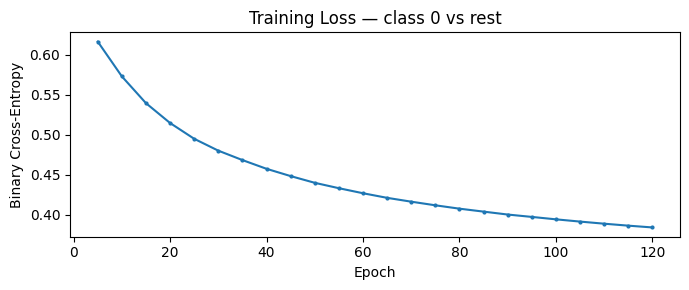

Train accuracy (binary, class 0 vs rest): 0.9300
Baseline (predict all-negative): 0.9441
Final logged loss: 0.3842


In [16]:
# Section 3 — Binary sanity check
CHECK_CLASS = sorted(np.unique(y_train))[0]  # first class
y_binary = (y_train == CHECK_CLASS).astype(np.float32)

clf = LogisticRegression(
    lr_decay=CONFIG['LR_DECAY'],
    l2_lambda=CONFIG['L2_LAMBDA'],
    loss_eval_every=CONFIG['LOSS_EVAL_EVERY'],
    use_class_weights=CONFIG['USE_CLASS_WEIGHTS'],
    use_prior_bias=CONFIG['USE_PRIOR_BIAS'],
)
clf.train(X_train, y_binary,
          bs=CONFIG['BATCH_SIZE'],
          epochs=CONFIG['EPOCHS'],
          lr=CONFIG['LR'])

# Loss curve (logged every LOSS_EVAL_EVERY epochs)
plt.figure(figsize=(7, 3))
plt.plot(clf.loss_epochs, clf.loss_history, marker='o', markersize=2)
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy')
plt.title(f'Training Loss — class {CHECK_CLASS} vs rest')
plt.tight_layout()
plt.show()

preds_binary = clf.predict(X_train)
acc = accuracy_score(y_binary, preds_binary)
print(f'Train accuracy (binary, class {CHECK_CLASS} vs rest): {acc:.4f}')
print(f'Baseline (predict all-negative): {1 - y_binary.mean():.4f}')
print(f'Final logged loss: {clf.loss_history[-1]:.4f}')

## Section 4 — Multi-Class OvR (Deliverable 1b)

Train one binary `LogisticRegression` per class, then use `np.argmax` over probabilities.

In [ ]:
# Section 4 — Multi-Class One-vs-Rest
class MultiClassLogisticRegression:
    """One-vs-Rest multi-class classifier built on top of LogisticRegression."""

    def __init__(self, bs=256, epochs=100, lr=0.1, lr_decay=0.0, l2_lambda=0.0,
                 loss_eval_every=1, use_class_weights=False, use_prior_bias=False):
        self.bs = bs
        self.epochs = epochs
        self.lr = lr
        self.lr_decay = lr_decay
        self.l2_lambda = l2_lambda
        self.loss_eval_every = loss_eval_every
        self.use_class_weights = use_class_weights
        self.use_prior_bias = use_prior_bias
        self.classifiers = []   # one per class
        self.classes_ = None    # sorted unique label values

    def fit(self, X, y):
        self.classes_ = np.sort(np.unique(y))
        self.classifiers = []
        n_classes = len(self.classes_)

        for i, c in enumerate(self.classes_):
            y_binary = (y == c).astype(np.float32)
            clf = LogisticRegression(
                lr_decay=self.lr_decay,
                l2_lambda=self.l2_lambda,
                loss_eval_every=self.loss_eval_every,
                use_class_weights=self.use_class_weights,
                use_prior_bias=self.use_prior_bias,
            )
            clf.train(X, y_binary, bs=self.bs, epochs=self.epochs, lr=self.lr)
            self.classifiers.append(clf)
            if (i + 1) % 10 == 0 or (i + 1) == n_classes:
                print(f'  Trained {i + 1}/{n_classes} classifiers '
                      f'(last logged loss: {clf.loss_history[-1]:.4f})')

    def predict_proba(self, X):
        """Returns (n_samples, n_classes) probability matrix."""
        return np.column_stack([
            clf.predict_proba(X) for clf in self.classifiers
        ])

    def predict(self, X):
        """Returns predicted label_id for each sample."""
        proba = self.predict_proba(X)          # (n_samples, n_classes)
        indices = np.argmax(proba, axis=1)     # index into self.classes_
        return self.classes_[indices]


print('MultiClassLogisticRegression class defined.')
print(f"Training {len(np.unique(y_train))} OvR classifiers — this takes a while...")

ovr = MultiClassLogisticRegression(
    bs=CONFIG['BATCH_SIZE'],
    epochs=CONFIG['EPOCHS'],
    lr=CONFIG['LR'],
    lr_decay=CONFIG['LR_DECAY'],
    l2_lambda=CONFIG['L2_LAMBDA'],
    loss_eval_every=CONFIG['LOSS_EVAL_EVERY'],
    use_class_weights=CONFIG['USE_CLASS_WEIGHTS'],
    use_prior_bias=CONFIG['USE_PRIOR_BIAS'],
)
ovr.fit(X_train, y_train)
print('Training complete.')

MultiClassLogisticRegression class defined.
Training 39 OvR classifiers — this takes a while...


In [7]:
# Evaluate on train set
train_preds = ovr.predict(X_train)
train_f1 = f1_score(y_train, train_preds, average='macro')
print(f'Train Macro F1 (our OvR LR): {train_f1:.4f}')

# Sklearn reference (for sanity check only — not used for submission)
from sklearn.linear_model import LogisticRegression as SklearnLR
sk_clf = SklearnLR(max_iter=1000, random_state=42)
sk_clf.fit(X_train, y_train)
sk_preds_train = sk_clf.predict(X_train)
sk_f1 = f1_score(y_train, sk_preds_train, average='macro')
print(f'Train Macro F1 (sklearn LR reference): {sk_f1:.4f}')

Train Macro F1 (our OvR LR): 0.4091
Train Macro F1 (sklearn LR reference): 0.6947


## Section 5 — Generate Submission (Deliverable 1c)

In [9]:
# Section 5 — Generate submission
test_preds = ovr.predict(X_test)

submission = pd.DataFrame({'id': test_ids, 'label_id': test_preds})
out_path = os.path.join(CONFIG['SUBMISSIONS_DIR'], 'LogReg_Prediction.csv')
submission.to_csv(out_path, index=False)

print(f'Saved: {out_path}')
print(f'Shape: {submission.shape}')
submission.head()

Saved: submissions/LogReg_Prediction.csv
Shape: (34790, 2)


,id,label_id
0,173148,12
1,29098,4
2,28211,4
3,136101,0
4,97133,14


## Section 6 — Results & Comparison

In [12]:
# Section 6 — Results summary
# Kaggle public score from latest submission
kaggle_f1 = 0.386

print('=== Task 1 Results ===')
print(f'Our OvR LR  — Train Macro F1 : {train_f1:.4f}')
print(f'Sklearn LR  — Train Macro F1 : {sk_f1:.4f}')
print(f'Kaggle Test — Macro F1       : {kaggle_f1}')
print()
print('Note:')
print('- Sklearn LogisticRegression is used only as an optional reference sanity check.')
print('- It is NOT used for the core Task 1 algorithm implementation, training pipeline, or Kaggle submission generation.')
print()
print('Analysis:')
print('- Train F1 gap (sklearn - ours):', round(sk_f1 - train_f1, 4))
print('  This gap is a sanity signal, not a correctness proof.')
print('  Our implementation is functionally correct (training + inference run end-to-end),')
print('  but performance can still differ due to optimization choices and hyperparameters.')
print('  Kaggle F1 = 0.386 suggests this Task 1 baseline is weaker than our best Task 2 models.')

=== Task 1 Results ===
Our OvR LR  — Train Macro F1 : 0.4091
Sklearn LR  — Train Macro F1 : 0.6947
Kaggle Test — Macro F1       : 0.386

Note:
- Sklearn LogisticRegression is used only as an optional reference sanity check.
- It is NOT used for the core Task 1 algorithm implementation, training pipeline, or Kaggle submission generation.

Analysis:
- Train F1 gap (sklearn - ours): 0.2855
  This gap is a sanity signal, not a correctness proof.
  Our implementation is functionally correct (training + inference run end-to-end),
  but performance can still differ due to optimization choices and hyperparameters.
  Kaggle F1 = 0.386 suggests this Task 1 baseline is weaker than our best Task 2 models.
